``` bash
python launch_sst2_pdb.py -pdb 5awl.pdb -dir tmp_CLN025_sst2_10_rung_5awl -n CLN025 -pad 1.5 -eq_time_expl 10 -time 1000 -temp_num 10 -min_temp 280 -temp_time 10
```

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import MDAnalysis as mda
import nglview as nv 
from scipy.ndimage import gaussian_filter1d
from cmcrameri import cm

import sys
sys.path.insert(0, '../src/')
import SST2
import SST2.analysis.data_plot as data_plot
import SST2.analysis.trajectory as trajectory

print(f"Using SST2 version: {SST2.__path__}")

/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


Using SST2 version: ['/home/murail/Documents/Code/SST2/notebook/../src/SST2']


In [2]:
ls ..

bin/              src/
build/            SST2.egg-info/
dist/             tmp_2HPL_no_pep.pdb
docs/             tmp_2HPL_only_pep.pdb
environment.yml   tmp_AAAAA/
LICENSE           tmp_CLN020/
Makefile          tmp_CLN025_charmm36m/
notebook/         tmp_launch_simulated_tempering_implicit_xml.py
pyproject.toml    tmp.pdb
README.md         TODO.md
requirements.txt


In [3]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (5, 3.5)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 8

sns.set_theme(
    context="paper",
    style="white",
    rc = {
    'axes.grid' : True,
    "grid.color": 'grey',
    "grid.linestyle": 'dotted',
    'xtick.bottom': True,
    'xtick.top': False,
    'ytick.left': True,
    'ytick.right': False,
})
sns.set_palette("tab10")

- Here I'll analyze the result of this SST2 simulation:

```
python bin/launch_SST2_abinitio_seq.py -seq YYDPETGTWY -dir tmp_CLN025_charmm36m -temp_num 8 -n CLN025 -ff charmm36 -eq_time_impl 1.0 -eq_time_expl 1.0
```


In [4]:
name = 'CLN025'

OUT_PATH = f'../tmp_CLN025_charmm36m/'
colorscale = cm.roma
ref_coor = [f'5awl.pdb']

ref_name = ref_coor[0][:4]

name_fig = f'tmp_{name}_8_rung_500K_charmm36m_1'
OUT_FIG = 'fig'

start_pdb = f'{OUT_PATH}/{name}_water.pdb'
first_pdb = f'{OUT_PATH}/{name}_water.pdb'

max_graph_point = 50000
skip_frame = 20
dt = 0.004

ref_Sel = "protein and chainID A and resid 2:9"
pep_Sel = "protein and chainID A and resid 2:9"

show_weights = True
use_only_300 = False

if not os.path.exists(OUT_FIG):
    os.makedirs(OUT_FIG)

time_ax_name = r"$Time\;(\mu s)$"

In [5]:
df_all = data_plot.read_SST2_data(
    f'{OUT_PATH}/{name}_sst2',
    dt=dt)

solute_scale_cols = [col for col in df_all.columns if 'E frac ' in col]
df_all['E solute scaled (kJ/mole)'] = df_all[solute_scale_cols].sum(axis=1)

In [6]:
df_all.tail(5)

,Aim Temp (K),E frac 1.0 (kJ/mole),E solute not scaled (kJ/mole),E solvent (kJ/mole),E solvent-solute (kJ/mole),Step,Potential Energy (kJ/mole),Total Energy (kJ/mole),Temperature (K),Speed (ns/day),$Time\;(\mu s)$,Temp (K),lambda,$\lambda$,E solute scaled (kJ/mole)
786926,432.100,189.839,565.668,-83773.6,-2638.24,393461500,-76932.456382,-63203.390173,301.373814,738,1.573846,432.100,0.694284,0.69,189.839
786927,401.691,351.322,563.346,-83256.6,-3060.37,393462000,-76924.058007,-62764.719724,310.818938,738,1.573848,401.691,0.746843,0.75,351.322
786928,432.100,276.911,428.843,-83257.7,-2838.54,393462500,-76896.788474,-63454.917733,295.069438,738,1.573850,432.100,0.694284,0.69,276.911
786929,464.812,297.096,511.762,-83623.3,-2916.52,393463000,-76821.741206,-63180.138269,299.453862,738,1.573852,464.812,0.645422,0.65,297.096
786930,432.100,194.855,553.763,-83646.8,-2749.33,393463500,-76874.354880,-62977.065059,305.066577,738,1.573854,432.100,0.694284,0.69,194.855


In [7]:
temp_list = df_all['Aim Temp (K)'].unique()
temp_num = len(temp_list)
min_temp = temp_list[0]
max_temp = temp_list[-1]
print(f' {temp_num} Temperature ladder, min={min_temp:.1f} max={max_temp:.1f}')

 8 Temperature ladder, min=300.0 max=500.0


## Exchange probability & Round trip time


Temp change freq   = 0.769
Round trip time is = 0.260 ns 


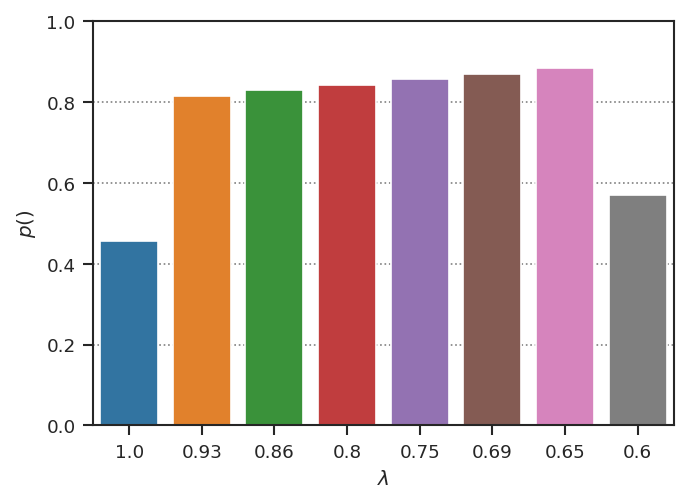

In [8]:
ex_prob, trip_time = data_plot.compute_exchange_prob(
    df_all,
    exchange_time=2,
    temp_col=r'$\lambda$')

plt.ylim(0,1)
print(f'Temp change freq   = {ex_prob:.3f}')
if trip_time is not None:
    print(f"Round trip time is = {trip_time:.3f} ns ")

## Temperature swap

<Axes: xlabel='$Time\\;(\\mu s)$', ylabel='Aim Temp (K)'>

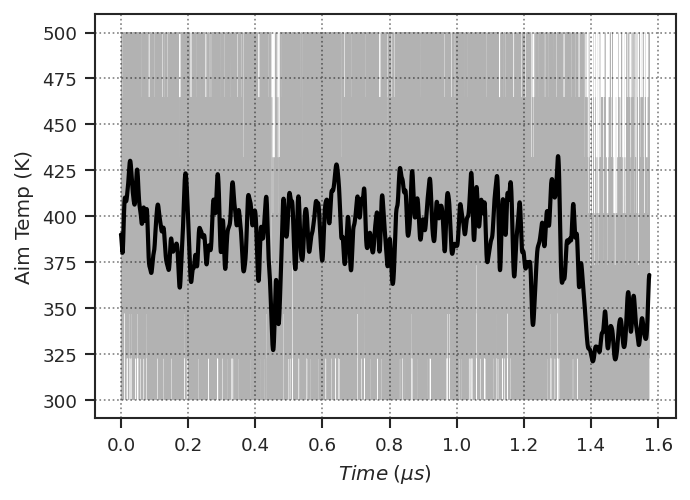

In [9]:
data_plot.plot_lineplot_avg(
    df_all,
    x=time_ax_name,
    y='Aim Temp (K)',
    max_data=max_graph_point,
    avg_win=100)

In [10]:
df_all['lambda'] = 300/df_all['Aim Temp (K)']

df_all['E solvent-solute (kJ/mole) scaled'] = 0.5*(df_all['lambda'])**0.5 * df_all['E solvent-solute (kJ/mole)'] 

df_all["new_pot"] = df_all['E solute scaled (kJ/mole)']  +\
    0.5*(df_all['lambda'])**0.5 * df_all['E solvent-solute (kJ/mole)'] 

In [11]:
if False:
    analysis.plot_energie_swap_convergence_diff(
        df_all, lag_num = 3,
        ylabel=r'$\Delta E_{pp} + \frac{1}{2} \sqrt{\frac{\beta_0}{\beta_m}} E_{pw}\; (KJ.mol^{-1})$',
        avg_start=10)

In [12]:
if False:
    plt.rcParams['figure.figsize'] = (5, 13.5)
    analysis.plot_energie_swap_convergence(
        df_all, lag_num = 25,
        ylabel=r'$\Delta E_{pp} + \frac{1}{2} \sqrt{\frac{\beta_0}{\beta_m}} E_{pw}\; (KJ.mol^{-1})$',
        split_graph=False, avg_start=5)

    plt.savefig(f'{OUT_FIG}/{name_fig}_e_swap.pdf', bbox_inches='tight')

    plt.rcParams['figure.figsize'] = (5, 3.5)

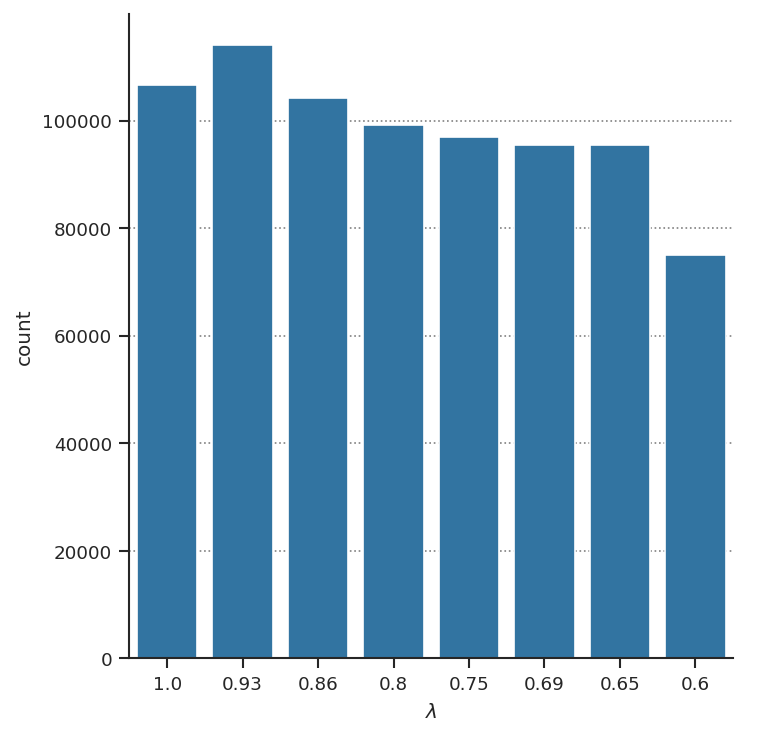

In [13]:
sns.catplot(
    df_all,
    x=r'$\lambda$',
    kind="count",                    
)
plt.savefig(f'{OUT_FIG}/{name_fig}_rung_dens.png')

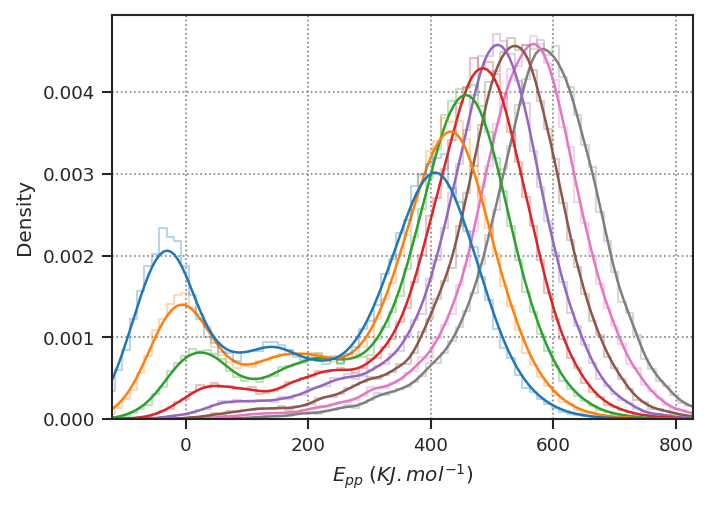

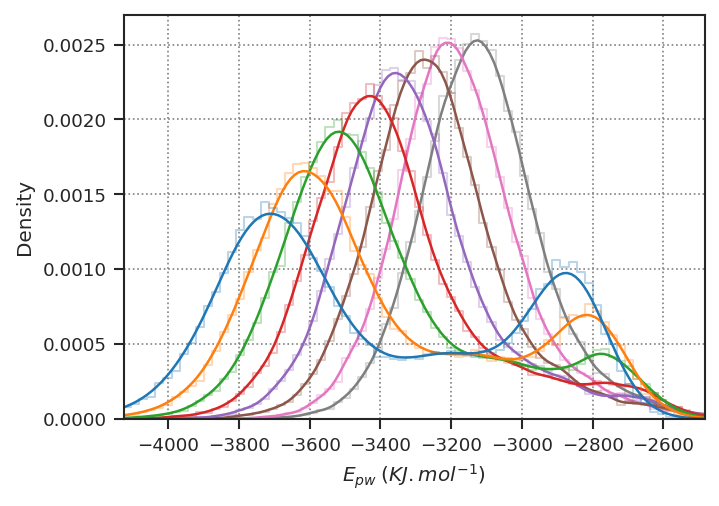

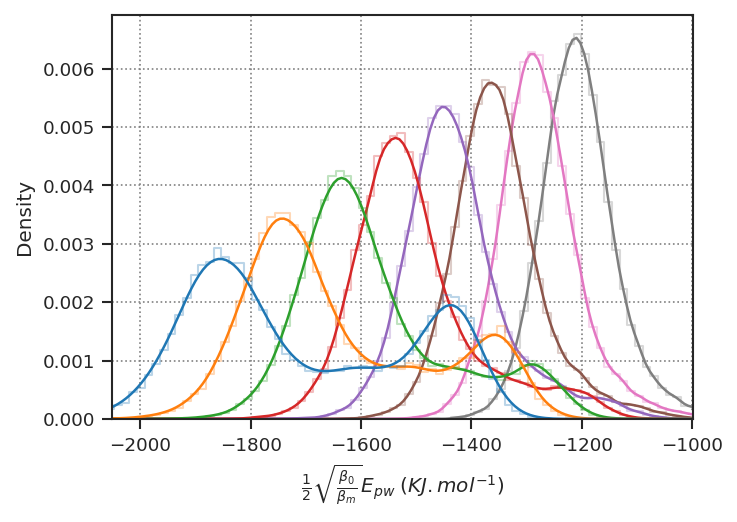

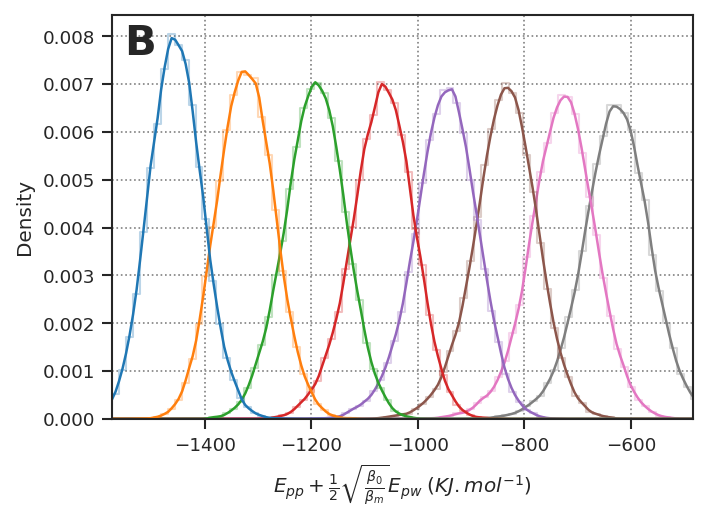

In [14]:
x_list = ["E solute scaled (kJ/mole)",
          'E solvent-solute (kJ/mole)',
          'E solvent-solute (kJ/mole) scaled',
          "new_pot"]

x_label_list = [
    r'$E_{pp}\; (KJ.mol^{-1})$',
    r'$E_{pw}\; (KJ.mol^{-1})$',
    r'$\frac{1}{2}\sqrt{\frac{\beta_0}{\beta_m}} E_{pw}\; (KJ.mol^{-1})$',
    r'$E_{pp} + \frac{1}{2} \sqrt{\frac{\beta_0}{\beta_m}} E_{pw}\; (KJ.mol^{-1})$']

label_num = 0

for x, x_label in zip(x_list, x_label_list):
    label_num += 1
    ax = data_plot.plot_distri_norm(
        df_all, 
        x=x,
        hue=r"$\lambda$",
        x_label=x_label,
        max_data=500000,
        bins=100, quant=0.001
    )
    #plt.grid()
    #plt.show()

    if label_num == 4:
        ax.text(0.02, 0.90, "B", transform=ax.transAxes, 
                size=20, weight='bold')
    
    ax.get_legend().remove()
    plt.savefig(f'{OUT_FIG}/{name_fig}_e_distri_{label_num}.pdf', dpi=300, bbox_inches='tight')

<Axes: xlabel='$E_{pp}\\;(KJ.mol^{-1})$', ylabel='$E_{pw}\\;(KJ.mol^{-1})$'>

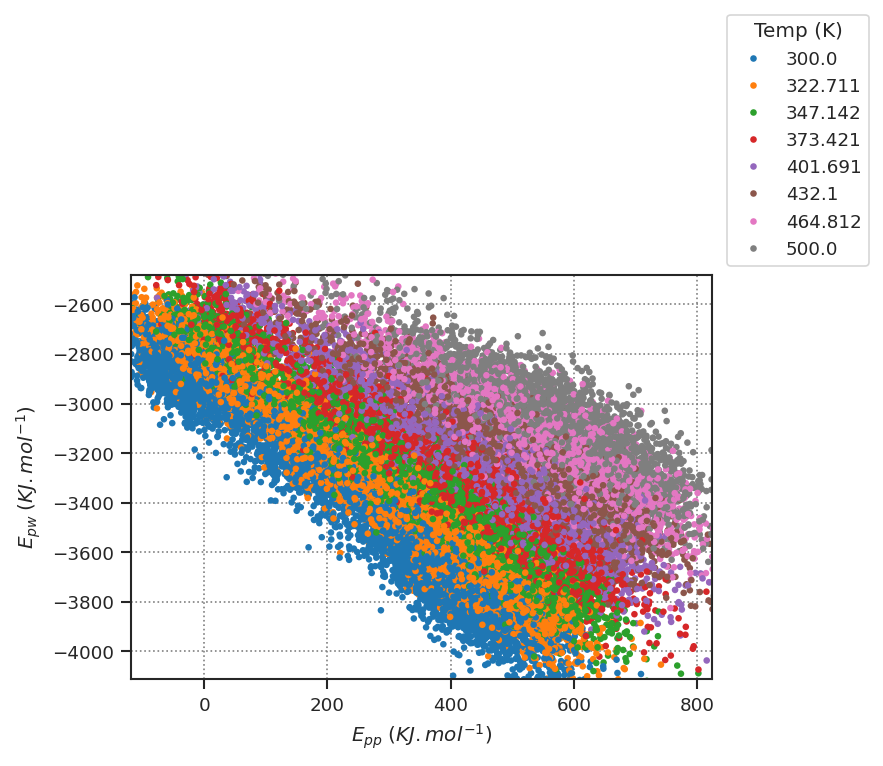

In [15]:
data_plot.plot_scatter(
    df_all,
    'E solute scaled (kJ/mole)',
    'E solvent-solute (kJ/mole)',
    "Temp (K)",
    r'$E_{pp}\;(KJ.mol^{-1})$',
    r'$E_{pw}\;(KJ.mol^{-1})$',
    quant=0.001
)

#plt.legend(title="Temp (K)", bbox_to_anchor=(1.0, 0.3))

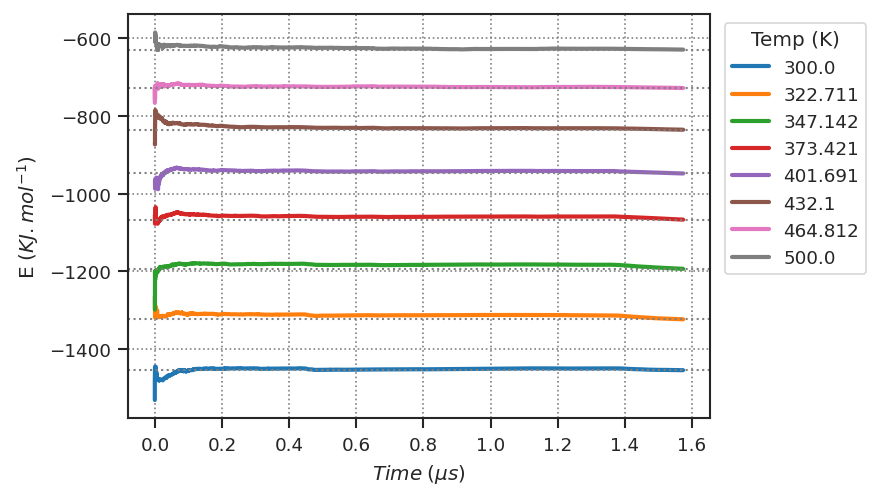

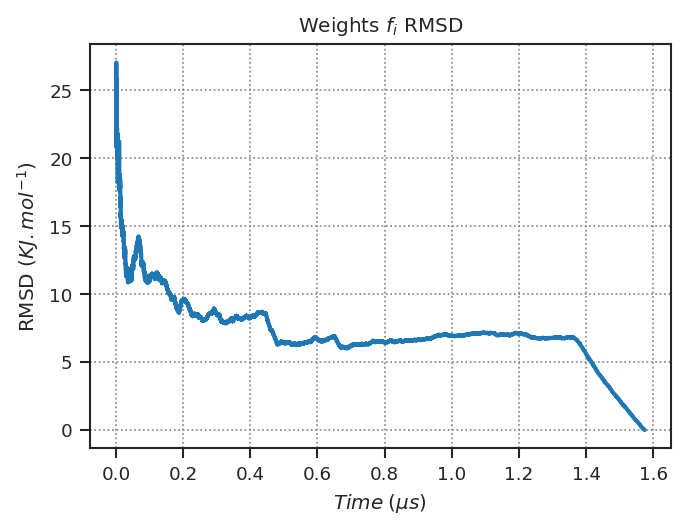

In [16]:
if show_weights:
    data_plot.plot_weight_RMSD(df_all, plot_weights=True)
    #plt.grid()

In [17]:
#df_tmp = analysis.compute_trapezoid_sst2_weights(df_all)

### Save only every 10 steps

```
mdconvert villin_10_micros_sim_temp_fly/villin_sim_temp.dcd -o villin_10_micros_sim_temp_fly/villin_sim_temp_skip100.xtc -s 20
```

In [18]:
md = trajectory.read_traj(
    start_pdb,
    f'{OUT_PATH}/{name}_sst2')

md_noh = md.select_atoms("protein and not name H*")

/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [19]:
print(f'traj len : {len(md.trajectory)}')
print(f'all csv  : {len(df_all)/20}')

traj len : 39351
all csv  : 39346.55


In [20]:
df_all = df_all[::20].reset_index()

In [21]:
print(f'traj len : {len(md.trajectory)}')
print(f'all csv  : {len(df_all)}')

max_step = min([len(md.trajectory), len(df_all)])
print(f'Max step = {max_step}')

df_all = df_all[:max_step]
step_300K_index = np.where(df_all['Aim Temp (K)'] == min_temp)[0]
print(len(step_300K_index))

traj len : 39351
all csv  : 39347
Max step = 39347
5442


In [22]:
steps_num = len(step_300K_index)

md_step = 1

while steps_num > max_graph_point:
    md_step += 1
    steps_num = len(step_300K_index) // md_step

print(md_step, len(step_300K_index) // md_step)

1 5442


In [23]:
md_noh.write(f'{OUT_PATH}/noh_300K_skip.pdb',
             frames=md.trajectory[:1])
if use_only_300:
    md_noh.write(f'{OUT_PATH}/noh_300K_skip.xtc',
                 frames=md.trajectory[step_300K_index][::md_step],
                 verbose=True)
    traj_filter = f'{OUT_PATH}/noh_300K_skip.xtc'
    df_300 = df_all.loc[step_300K_index][::md_step].reset_index()
    df_300.to_csv(f'{OUT_PATH}/300K_data.csv', index=False, index_label=None)

/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1153: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"


In [24]:
if not use_only_300:
    steps_num = len(md.trajectory)

    #md_step = 1
    #while steps_num > max_graph_point:
    #    md_step += 1
    #    steps_num = len(md.trajectory) // md_step
    md_step = skip_frame

    print(md_step, len(md.trajectory) // md_step)

    df_300 = df_all.loc[:max_step:md_step].reset_index()
    df_300.to_csv(f'{OUT_PATH}/all_data.csv', index=False, index_label=None)

    print(len(df_300))
    
    md_noh.write(f'{OUT_PATH}/noh_skip.xtc',
             frames=md.trajectory[:max_step:md_step],
             verbose=True)
    traj_filter = f'{OUT_PATH}/noh_skip.xtc'

20 1967
1968


In [25]:
#%%time
#%%bash -s "$start_pdb" "$traj_xtc" "$md_step" "$out_pre" "$max_step"
#echo $1 $2 $3 $4 $5
#vmd -e filter_xtc.tcl -dispdev text -args $1 $2 $3 $4 $5

In [26]:
for ref in ref_coor:
    if not os.path.exists(ref):
        import pdb_numpy
        print(f"Generating reference pdb file {ref} from pdb id {ref[:4]}")
        coor = pdb_numpy.Coor(pdb_id=ref[:4])
        coor.write(ref)

ref = mda.Universe(*ref_coor)

import openmm.app as app

pdbfile = app.PDBFile(f'{OUT_PATH}/noh_300K_skip.pdb')

md = mda.Universe(pdbfile,
                  traj_filter,
                  in_memory=True)

/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/coordinates/XDR.py:240: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "


In [27]:
print(f'traj len : {len(md.trajectory)}')
print(f'all csv  : {len(df_300)}')


traj len : 1968
all csv  : 1968


In [28]:
trajectory.prepare_traj(md, ref_Sel)
trajectory.align_traj(md, ref, ref_Sel, tol_mass=10)
trajectory.align_traj(ref, ref, ref_Sel, tol_mass=10)

IntProgress(value=0, max=1968)

/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/core/groups.py:445: DeprecationWarning: The 'pbc' kwarg has been deprecated and will be removed in version 3.0., please use 'wrap' instead
  warnings.warn("The 'pbc' kwarg has been deprecated and will be "


  0%|          | 0/1968 [00:00<?, ?it/s]

/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/core/universe.py:658: UserWarning: Reader has no dt information, set to 1.0 ps
  dt=self.trajectory.ts.dt * step,


  0%|          | 0/1 [00:00<?, ?it/s]

In [29]:
import MDAnalysis.analysis.rms

R = MDAnalysis.analysis.rms.RMSD(
        md,
        ref,
        select=f"backbone and ({ref_Sel})",
        groupselections=[f"backbone and ({pep_Sel})"],
        verbose=True)
R.run()

rmsd = R.results.rmsd.T
df_300['RMSD (nm)'] = rmsd[3] / 10

  0%|          | 0/1968 [00:00<?, ?it/s]

<Axes: xlabel='$Time\\;(\\mu s)$', ylabel='RMSD (nm)'>

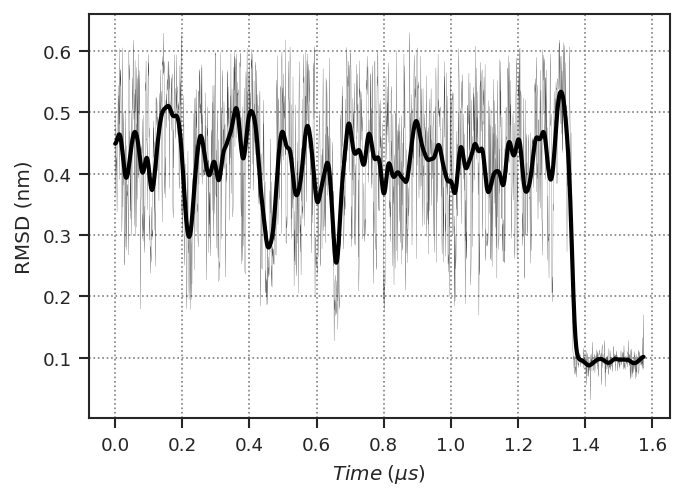

In [30]:
data_plot.plot_lineplot_avg(
    df_300,
    x=time_ax_name,
    y="RMSD (nm)",
    avg_win=10,
    alpha=0.9)

In [31]:
first_md = mda.Universe(first_pdb,
                        in_memory=True)

CA_pep_ref = first_md.select_atoms(f"({pep_Sel}) and name CA")
ref_com = CA_pep_ref.center_of_mass()
print("Ref Com",ref_com)

CA_pep = md.select_atoms(f"({pep_Sel}) and name CA")

com_dist = []

for ts in md.trajectory:
    #print("Frame: {0:5d}, Time: {1:8.3f} ps".format(ts.frame, md.trajectory.time))
    com = CA_pep.center_of_mass()
    com_dist.append(np.linalg.norm(ref_com - com))

df_300['COM dist (Å)'] = com_dist

Ref Com [12.02487496  5.74062496  7.38687506]


/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/core/universe.py:658: UserWarning: Reader has no dt information, set to 1.0 ps
  dt=self.trajectory.ts.dt * step,


In [32]:
com_dist_show = False

if com_dist_show:
    df_300['COM dist (Å)'] = com_dist
    df_300['COM_dist_sig6'] = gaussian_filter1d(df_300["COM dist (Å)"], 50)

    ax = sns.scatterplot(
        data=df_300,
        x=time_ax_name,
        y='COM dist (Å)',
        linewidth=0, s=2)

    ax = sns.scatterplot(
        data=df_300,
        x=time_ax_name,
        y="COM_dist_sig6",
        linewidth=0, s=2)

## Compute proline omega angle 

In [33]:
from MDAnalysis.analysis import dihedrals

omegas = [md.residues[i-1].omega_selection() for i, res in enumerate(md.residues) if res.resname == "PRO" and i > 0]
omegas[0].dihedral.value()

dihs = dihedrals.Dihedral(omegas).run(verbose=True)

for i in range(len(dihs.angles.T)):
    df_300[f'omega_{i}'] = dihs.angles.T[i]

  0%|          | 0/1968 [00:00<?, ?it/s]

/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/analysis/dihedrals.py:315: DeprecationWarning: The `angle` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.angles` instead
  warnings.warn(wmsg, DeprecationWarning)


/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/analysis/dihedrals.py:315: DeprecationWarning: The `angle` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.angles` instead
  warnings.warn(wmsg, DeprecationWarning)


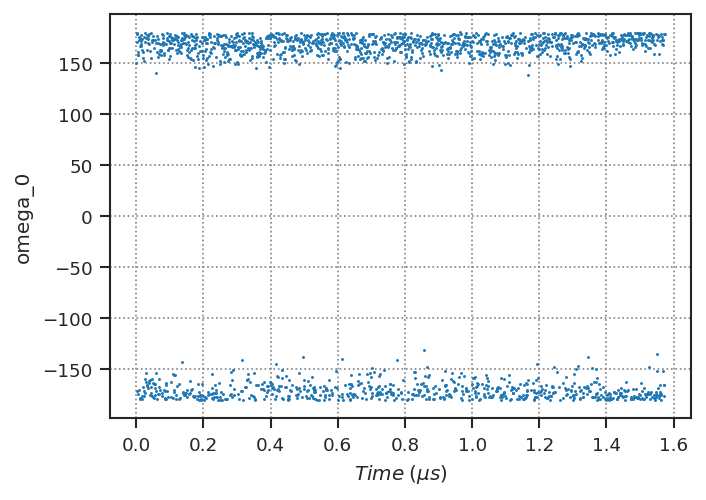

In [34]:
for i in range(len(dihs.angles.T)):
    sns.scatterplot(
        data=df_300,
        x=time_ax_name,
        y=f'omega_{i}',
        linewidth=0, s=2
    )

## Gyration radius

In [35]:
pep = md.select_atoms(f"({pep_Sel})")

gyr = []

for ts in md.trajectory:
    #print("Frame: {0:5d}, Time: {1:8.3f} ps".format(ts.frame, md.trajectory.time))
    gyr.append(pep.radius_of_gyration())

df_300['Gyration radius (nm)'] = [i/10 for i in gyr]

Text(0, 0.5, 'Gyration radius (nm)')

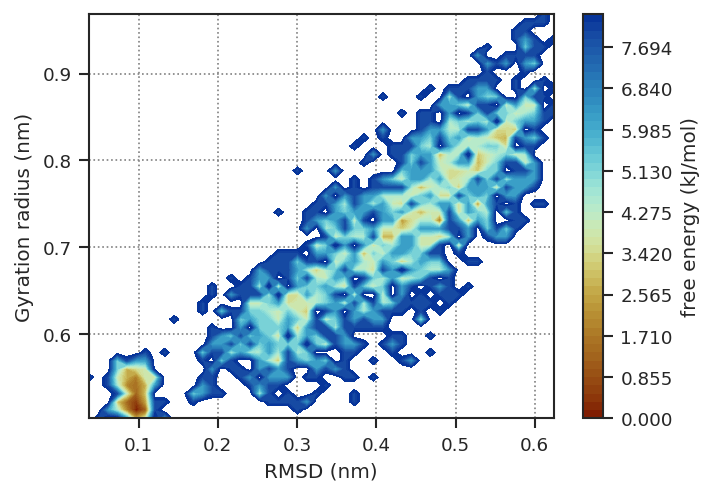

In [36]:
data_plot.plot_free_energy(
    df_300["RMSD (nm)"],df_300['Gyration radius (nm)'], 
    ncontours=50, nbins=50,
    cmap=colorscale)#,
    #avoid_zero_count=True)
plt.xlabel("RMSD (nm)")
plt.ylabel('Gyration radius (nm)')

<Axes: xlabel='Aim Temp (K)', ylabel='Gyration radius (nm)'>

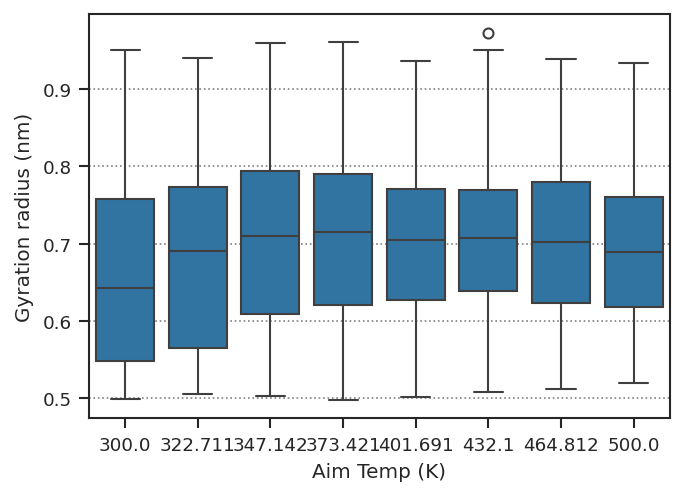

In [37]:
sns.boxplot(
    df_300,
    x='Aim Temp (K)',
    y='Gyration radius (nm)',
)

## Fraction of native contact

In [38]:
df_300['Native Contact'] = trajectory.compute_native_contact(md, ref, 'protein and not name H*')

  0%|          | 0/1968 [00:00<?, ?it/s]

/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/analysis/contacts.py:496: DeprecationWarning: The `timeseries` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.timeseries` instead
  warnings.warn(wmsg, DeprecationWarning)


<Axes: xlabel='$Time\\;(\\mu s)$', ylabel='Native Contact'>

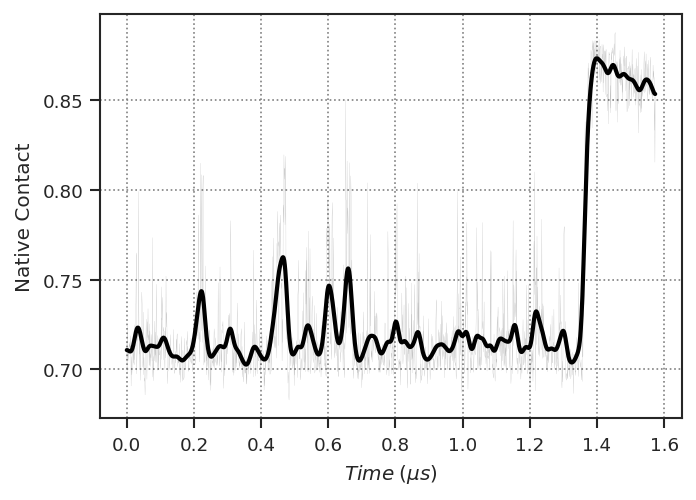

In [39]:
data_plot.plot_lineplot_avg(
    df_300,
    x=time_ax_name,
    y='Native Contact',
    avg_win=10)

Text(0, 0.5, 'Native contact')

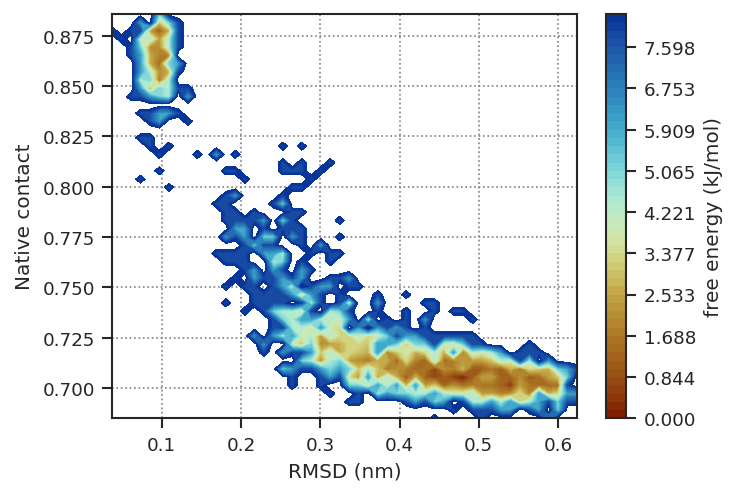

In [40]:
data_plot.plot_free_energy(
    df_300["RMSD (nm)"], df_300['Native Contact'], 
    ncontours=50, nbins=50,
    cmap=colorscale)#,
    #avoid_zero_count=True)
plt.xlabel("RMSD (nm)")
plt.ylabel('Native contact')

<Axes: xlabel='$Time\\;(\\mu s)$', ylabel='Potential Energy (kJ/mole)'>

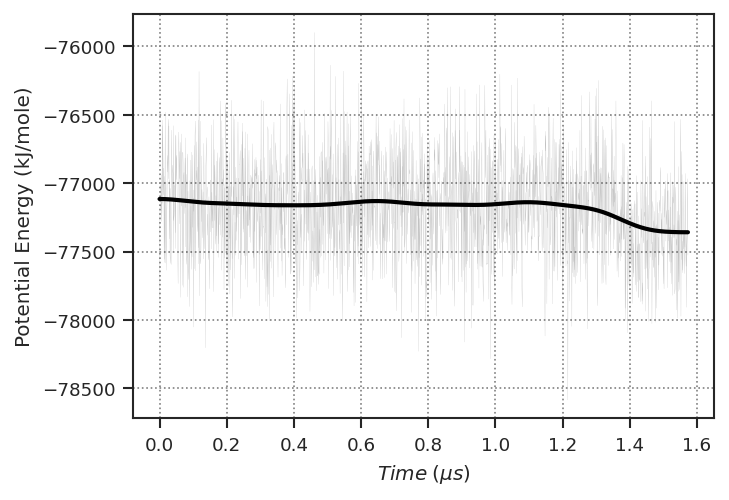

In [41]:
data_plot.plot_lineplot_avg(
    df_300,
    x=time_ax_name,
    y="Potential Energy (kJ/mole)",
    avg_win=100)

<Axes: xlabel='$Time\\;(\\mu s)$', ylabel='new_pot'>

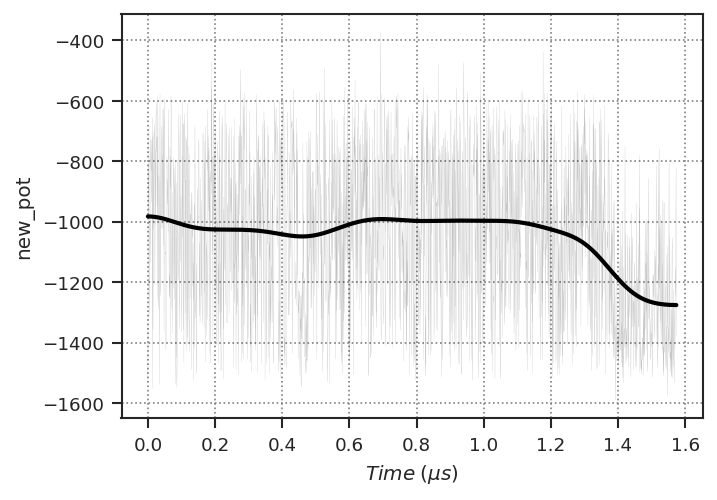

In [42]:
data_plot.plot_lineplot_avg(
    df_300,
    x=time_ax_name,
    y="new_pot",
    avg_win=100)

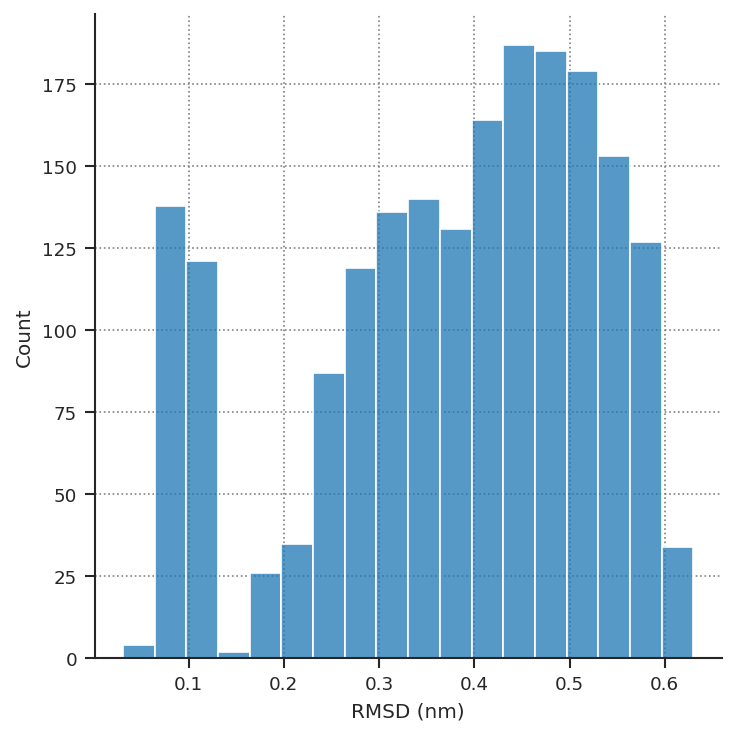

In [43]:
ax = sns.displot(df_300["RMSD (nm)"])

## Compute PCA

  0%|          | 0/1968 [00:00<?, ?it/s]

/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/analysis/pca.py:337: DeprecationWarning: The `cumulated_variance` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.cumulated_variance` instead.
  warnings.warn(wmsg, DeprecationWarning)


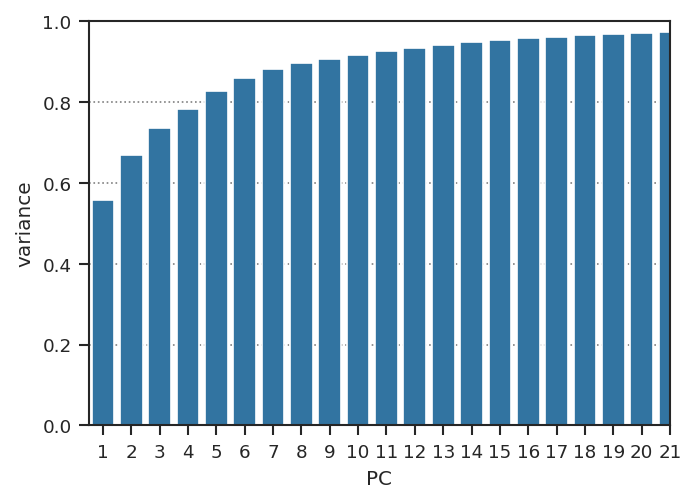

In [44]:
prot_pca, pca_df, pca_ref_df = trajectory.compute_pca(md, ref, sel='backbone', cum_var=0.8)
df_300['PC_1'] = pca_df['PC_1']
df_300['PC_2'] = pca_df['PC_2']

## Plot density for PC 1-2

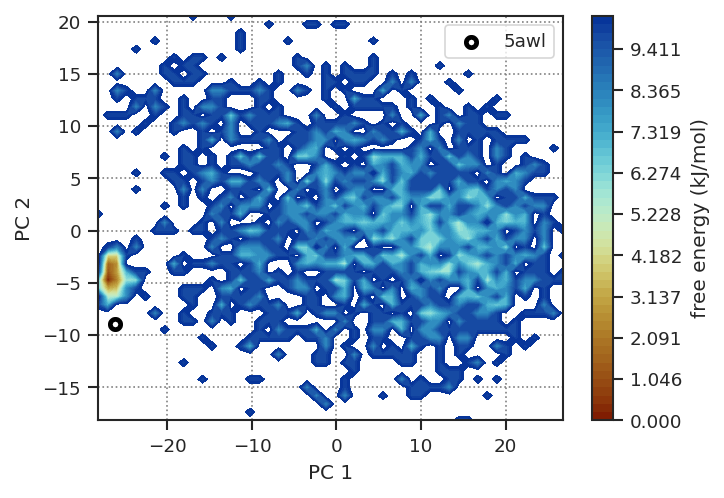

In [45]:
data_plot.plot_free_energy(
    pca_df.PC_1,
    pca_df.PC_2,
    nbins=50,
    ncontours=50,
    cmap=colorscale)#,
    #avoid_zero_count=True)

plt.scatter(pca_ref_df.PC_1, pca_ref_df.PC_2,
            color='white', s=5, linewidth=5,
            edgecolor = 'black',
            label=ref_name)
plt.legend()
plt.xlabel('PC 1')
plt.ylabel('PC 2')

plt.savefig(f'{OUT_FIG}/{name_fig}_PC_1_2_free_ener.png', dpi=300)

## Clustering with HDBSCAN

In [46]:
df_300['clust'] = data_plot.compute_cluster_hdbscan(pca_df)

<Axes: xlabel='$Time\\; (\\mu s)$', ylabel='cluster'>

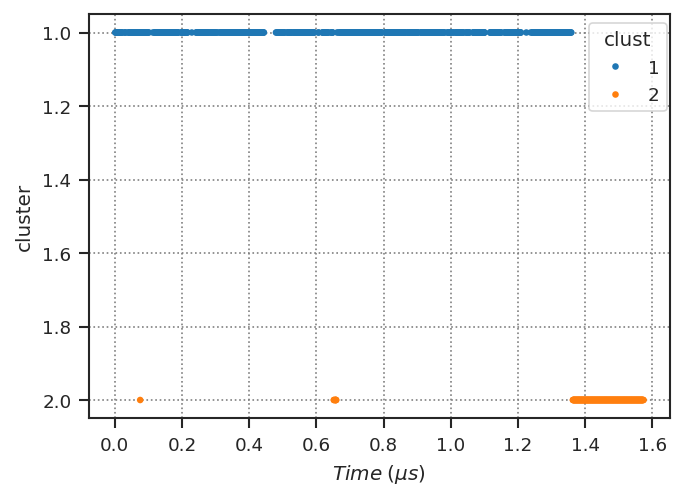

In [47]:
data_plot.plot_scatter(
    df_300,
    time_ax_name,
    "clust",
    "clust",
    x_label=r'$Time\; (\mu s)$',
    y_label=r'cluster')

<Axes: xlabel='$Time\\; (\\mu s)$', ylabel='$RMSD\\; (nm)$'>

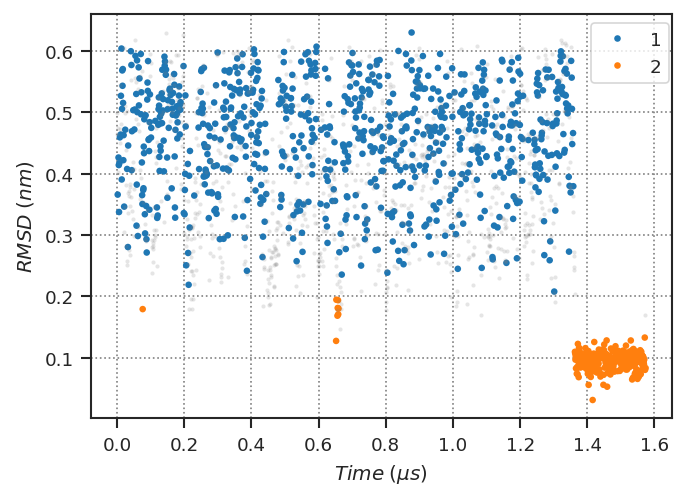

In [48]:
data_plot.plot_scatter(
    df_300,
    time_ax_name,
    "RMSD (nm)",
    "clust",
    x_label=r'$Time\; (\mu s)$',
    y_label=r'$RMSD\; (nm)$')

data_plot.plot_scatter(
    df_300[df_300.clust.isnull()],
    time_ax_name,
    "RMSD (nm)",
    x_label=r'$Time\; (\mu s)$',
    y_label=r'$RMSD\; (nm)$',
    color='gray', s=4, alpha=0.2,
    legend=False)

<Axes: xlabel='PC 1', ylabel='PC 2'>

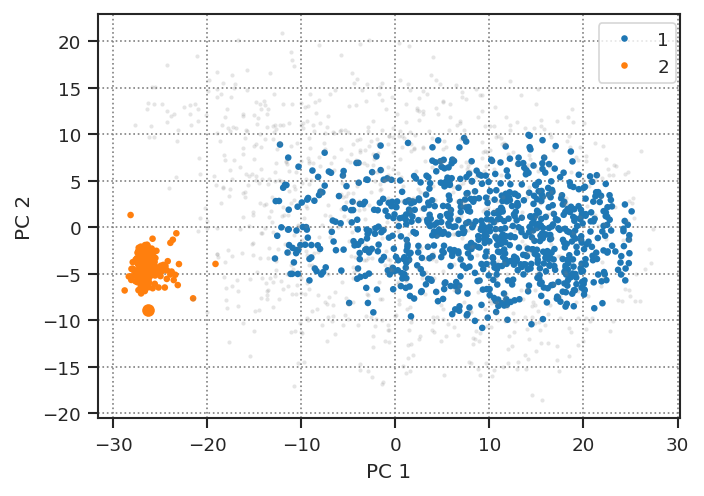

In [49]:
data_plot.plot_scatter(
    df_300,
    x="PC_1", y="PC_2", hue="clust",
    x_label="PC 1",
    y_label="PC 2")
data_plot.plot_scatter(
    df_300[df_300.clust.isnull()],
    x="PC_1", y="PC_2",
    x_label="PC 1",
    y_label="PC 2",
    color='gray', s=4, alpha=0.2,
    legend=False)
data_plot.plot_scatter(
    pca_ref_df,
    x="PC_1", y="PC_2",
    x_label="PC 1", label=ref_name,
    y_label="PC 2", s=50, linewidth=1)

<Axes: xlabel='PC_1', ylabel='PC_2'>

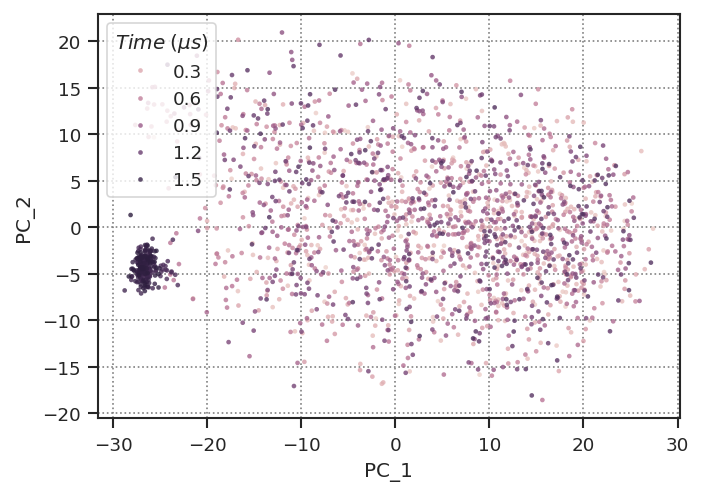

In [50]:
sns.scatterplot(data=df_300,
                x="PC_1", y="PC_2",
                hue=time_ax_name,
                s=5,
                alpha=0.8,
                linewidth=0)

In [51]:
center_frame = []

dt = md.trajectory.dt

md_noh = md.select_atoms(f"protein and not name H* and ({pep_Sel})")
md_noh.write("tmp_ref.pdb")

ref_tmp = mda.Universe('tmp_ref.pdb')
ref_sel = ref_tmp.select_atoms(f"protein and not name H* and ({pep_Sel})")

n_clusters_ = len(df_300['clust'].unique())

for clust in range(1, n_clusters_):
    indexes = [i for i, val in enumerate(df_300['clust']) if val==clust]
    print(f'Cluster : {clust:3}, num: {len(indexes):6}')
    
    # Compute avg structures:
    p_avg = np.zeros_like(md_noh.atoms.positions)

    # do a quick average of the protein (in reality you probably want to remove PBC and RMSD-superpose)
    for ts in md.trajectory[indexes]:
        p_avg += md_noh.atoms.positions
    p_avg /= len(indexes)
    ref_sel.atoms.positions = p_avg
    
    min_rmsd = np.inf
    step = 0
    frame = 0
    for ts in md.trajectory[indexes]:
        R = mda.analysis.rms.rmsd(md_noh.atoms.positions, ref_sel.atoms.positions)
        if R<min_rmsd:
            min_rmsd = R
            frame = ts.frame
            time= ts.time
    
    local_df = df_300[df_300.clust == clust]
    
    print(f'\t closest structure : {frame:6},   size= {len(indexes):6}   RMSD={local_df["RMSD (nm)"].mean():.2f}')
    center_frame.append([clust, frame, len(indexes)])

Cluster :   1, num:    817
	 closest structure :    735,   size=    817   RMSD=0.46
Cluster :   2, num:    271
	 closest structure :   1833,   size=    271   RMSD=0.10


/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1153: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1153: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1153: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn("Found no information for attr: '{}'"
/home/murail/miniforge3/envs/openmm/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1153: UserWarning: Found no information for attr: 'tempfactors' Using default value of '0.0'
  warnings.warn("Found no information for attr: '{}'"
/home/murail/miniforge3/envs/openmm/lib/pytho

In [52]:
df_300[df_300["RMSD (nm)"]<0.20]

,level_0,index,Aim Temp (K),E frac 1.0 (kJ/mole),E solute not scaled (kJ/mole),E solvent (kJ/mole),E solvent-solute (kJ/mole),Step,Potential Energy (kJ/mole),Total Energy (kJ/mole),...,E solvent-solute (kJ/mole) scaled,new_pot,RMSD (nm),COM dist (Å),omega_0,Gyration radius (nm),Native Contact,PC_1,PC_2,clust
95,1900,38000,464.812,455.807,467.618,-83649.0,-3100.47,18998500,-76816.165218,-63212.509737,...,-1245.430506,-789.623506,0.179286,15.346167,-175.738298,0.543662,0.773421,-21.479588,-7.629620,2
267,5340,106800,322.711,293.042,512.518,-82937.9,-3309.08,53398500,-77098.233518,-63368.676372,...,-1595.258304,-1302.216304,0.180083,15.501179,-171.937764,0.546665,0.786033,-14.722047,-4.797540,NaN
275,5500,110000,322.711,310.722,518.065,-82728.2,-3336.38,54998500,-77143.851072,-63300.516465,...,-1608.419228,-1297.697228,0.195044,15.417025,161.067575,0.605814,0.814934,-18.178795,-5.290632,NaN
279,5580,111600,464.812,321.300,441.079,-83212.2,-2850.89,55798500,-76533.753047,-62995.613080,...,-1145.176498,-823.876498,0.178746,15.340625,159.417778,0.574784,0.808473,-18.988962,-2.854735,NaN
283,5660,113200,401.691,518.008,541.990,-83877.4,-3325.45,56598500,-77241.370873,-63554.815983,...,-1436.927986,-918.919986,0.195117,15.405384,-168.674484,0.588360,0.797286,-16.012364,3.817712,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963,39260,785200,373.421,153.775,496.320,-83652.1,-2912.73,392598500,-77457.682895,-63692.633887,...,-1305.363581,-1151.588581,0.082944,15.450532,-176.087872,0.513572,0.862253,-27.009441,-4.275275,2
1964,39280,785600,347.142,181.883,464.136,-83291.0,-3072.47,392798500,-77346.602467,-63806.422686,...,-1428.120003,-1246.237003,0.132933,15.451690,178.363336,0.502573,0.833271,-28.122247,1.325363,2
1965,39300,786000,347.142,275.766,499.610,-83493.1,-3067.84,392998500,-77259.613942,-63603.079061,...,-1425.967925,-1150.201925,0.080293,15.479119,-165.730071,0.525630,0.848746,-26.051524,-3.861073,2
1966,39320,786400,432.100,369.916,476.250,-83909.1,-2859.00,393198500,-76968.071799,-63165.679505,...,-1191.112148,-821.196148,0.170206,15.516147,-165.539964,0.526529,0.815446,-23.345291,5.391873,NaN


In [53]:
df_300.tail()

,level_0,index,Aim Temp (K),E frac 1.0 (kJ/mole),E solute not scaled (kJ/mole),E solvent (kJ/mole),E solvent-solute (kJ/mole),Step,Potential Energy (kJ/mole),Total Energy (kJ/mole),...,E solvent-solute (kJ/mole) scaled,new_pot,RMSD (nm),COM dist (Å),omega_0,Gyration radius (nm),Native Contact,PC_1,PC_2,clust
1963,39260,785200,373.421,153.775,496.320,-83652.1,-2912.73,392598500,-77457.682895,-63692.633887,...,-1305.363581,-1151.588581,0.082944,15.450532,-176.087872,0.513572,0.862253,-27.009441,-4.275275,2
1964,39280,785600,347.142,181.883,464.136,-83291.0,-3072.47,392798500,-77346.602467,-63806.422686,...,-1428.120003,-1246.237003,0.132933,15.451690,178.363336,0.502573,0.833271,-28.122247,1.325363,2
1965,39300,786000,347.142,275.766,499.610,-83493.1,-3067.84,392998500,-77259.613942,-63603.079061,...,-1425.967925,-1150.201925,0.080293,15.479119,-165.730071,0.525630,0.848746,-26.051524,-3.861073,2
1966,39320,786400,432.100,369.916,476.250,-83909.1,-2859.00,393198500,-76968.071799,-63165.679505,...,-1191.112148,-821.196148,0.170206,15.516147,-165.539964,0.526529,0.815446,-23.345291,5.391873,NaN
1967,39340,786800,322.711,173.042,568.440,-83411.6,-3220.36,393398500,-77526.316648,-63882.908357,...,-1552.487710,-1379.445710,0.083327,15.452805,178.568851,0.541789,0.853264,-26.573063,-6.161081,2


In [54]:
view = nv.show_mdanalysis(md)
view.add_component(ref_coor[0])
view.clear_representations(1)
view[1].add_cartoon(selection="protein", color='blue')
view[1].add_licorice(selection=":A", color='blue')
view[0].add_licorice(selection=":A")

from ipywidgets import interact

def update(n):
    tail(df_300)
    local_df = df_300[df_300.clust == n]
    
    view.frame = center_frame[n-1][1]
    print(f"Cluster {n}, size={center_frame[n-1][2]}, frame={center_frame[n-1][1]}, RMSD={local_df['RMSD (nm)'].mean():.2f}")

interact(update, n=range(1, len(center_frame)+1));

view

interactive(children=(Dropdown(description='n', options=(1, 2), value=1), Output()), _dom_classes=('widget-int…

NGLWidget(max_frame=1967)

In [55]:
show_matrix = False

if show_matrix:

    from MDAnalysis.analysis import diffusionmap

    matrix = diffusionmap.DistanceMatrix(md, select=f'backbone and ({pep_Sel})',
                                         verbose=True, pairwise_align=False).run(step=20)

In [56]:
if show_matrix:
    
    # WARNING: time is not continuous as only 300K frames are shown

    max_RMSD = df_300["RMSD (nm)"].max() * 10 # Angstrom

    last_time = df_300.iloc[-1][time_ax_name]

    plt.imshow(matrix.dist_matrix,
               cmap='viridis',
               vmax=max_RMSD,
               extent=[0, last_time, last_time, 0])
    plt.xlabel(time_ax_name)
    plt.ylabel(time_ax_name)
    plt.colorbar(label=r'RMSD ($\AA$)')

In [57]:
print(f"vmd {OUT_PATH}/noh_300K_skip.pdb {traj_filter}"\
      f" -m ../REST2_test/{ref_coor[0]} -e ../REST2_test/visualize_pep.tcl")

vmd ../tmp_CLN025_charmm36m//noh_300K_skip.pdb ../tmp_CLN025_charmm36m//noh_skip.xtc -m ../REST2_test/5awl.pdb -e ../REST2_test/visualize_pep.tcl


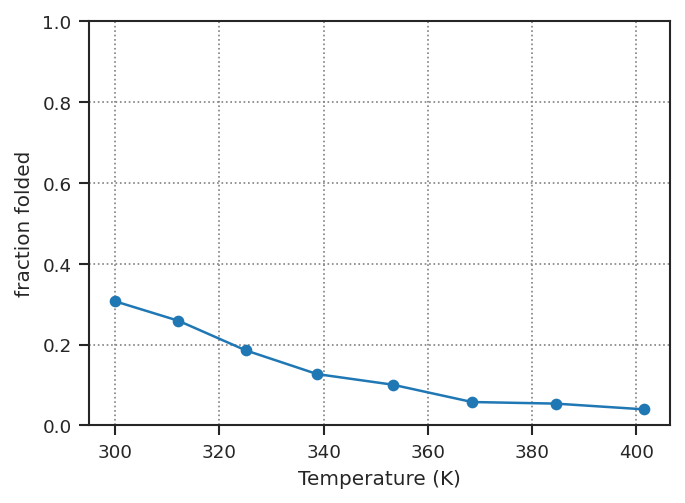

In [58]:
if not use_only_300:
    
    rmsd_cutoff = 0.2
    
    data_plot.plot_folding_fraction(
        df_300,
        cutoff=rmsd_cutoff,
        recompute_temp_flag=True,
        label=None)

In [59]:
df_300[r"$Time\;(\mu s)$"].max()

1.573594

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


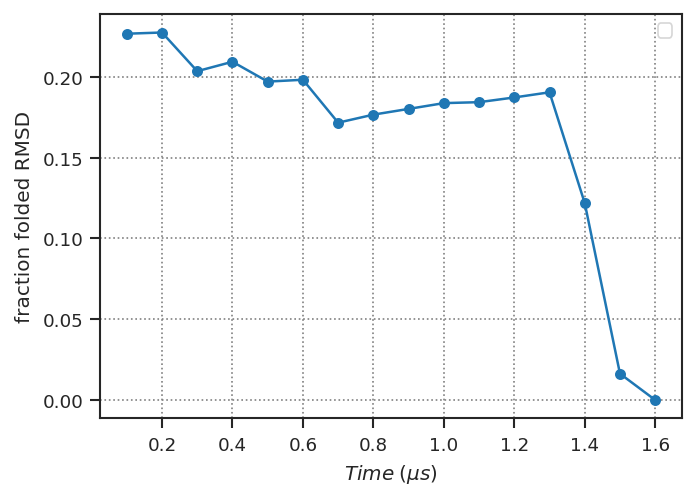

In [60]:
if not use_only_300:    
    data_plot.plot_folding_fraction_RMSD(
        df_300, time_interval=0.1,
        cutoff=rmsd_cutoff,
        start_time=0.0)

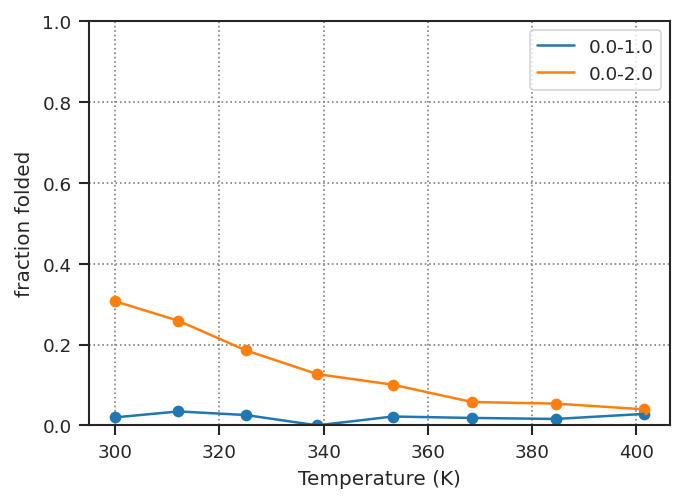

In [61]:
if not use_only_300:  
    
    data_plot.plot_folding_fraction_convergence(
        df_300, time_interval=1,
        recompute_temp_flag=True,
        cutoff=rmsd_cutoff,
        start_time=0.0)

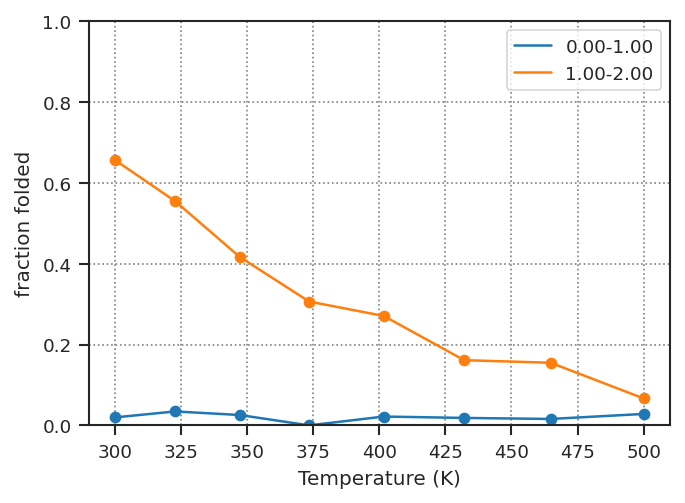

In [62]:

def plot_folding_fraction_interval(df, col="RMSD (nm)", cutoff=0.2, label=None,
    start_time=0, time_ax_name=r"$Time\;(\mu s)$", recompute_temp_flag=False,
    ref_temp=300.0, time_interval=2.0):

    temp_list = df['Aim Temp (K)'].unique()
    temp_list.sort()


    if recompute_temp_flag:
        if ref_temp not in temp_list:
            ref_temp = temp_list[np.argmin(abs(temp_list-300))]
        temp_list_plot = data_plot.recompute_temp(df, ref_temp=ref_temp)
    else:
        temp_list_plot = temp_list
    
    max_time = df[time_ax_name].max()
    #logger.info(max_time)
    
    for i in range( int((max_time-start_time)/time_interval) + 1):
        #print(f"{i}  {start_time:.1f}  {start_time + (i + 1) * time_interval:.1f}")
    

        df_time = df[(df[time_ax_name] > start_time + i * time_interval) &
                     (df[time_ax_name] < start_time + (i + 1) * time_interval)]
        
        fold_frac = data_plot.compute_folding_fraction(
            df_time, col, cutoff)
                
        plt.plot(temp_list_plot, fold_frac, label=f"{start_time + i * time_interval:.2f}-{start_time + (i + 1) * time_interval:.2f}")
        plt.scatter(temp_list_plot, fold_frac)
    
    plt.xlabel('Temperature (K)')
    plt.ylabel('fraction folded')
    plt.ylim((0,1.0))
    plt.legend()

plot_folding_fraction_interval(
    df_300,
    cutoff=0.2,
    time_interval=1,
    start_time=0.
)

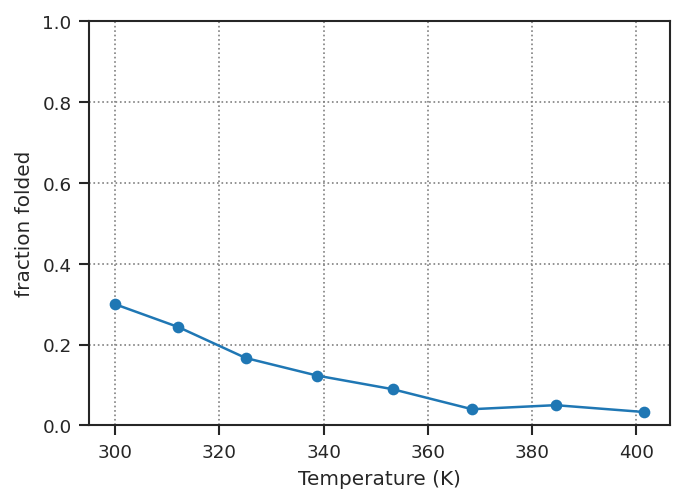

In [63]:
around_300 = temp_list[np.argmin(abs(temp_list-300))]


if not use_only_300:
    data_plot.plot_folding_fraction(df_300, ref_temp=around_300) #[df_300[time_ax_name]>0.15])

<Axes: xlabel='$Time\\;(\\mu s)$', ylabel='RMSD (nm)'>

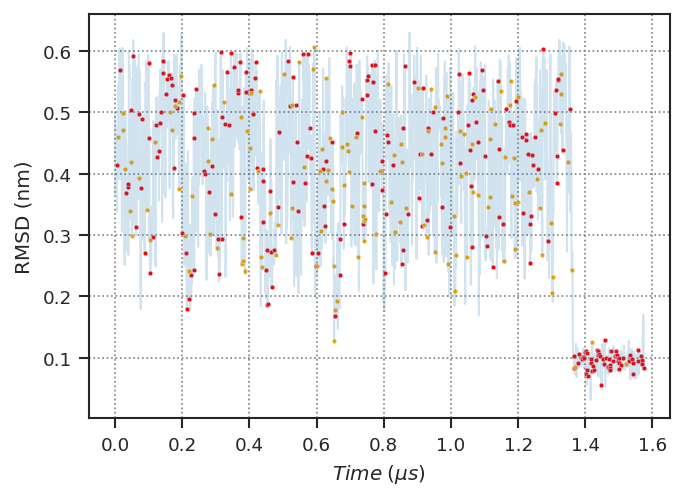

In [64]:
sns.lineplot(data=df_300,
             x=time_ax_name,
             y="RMSD (nm)", alpha=0.2, linewidth=1)
sns.scatterplot(data=df_300[df_300["Aim Temp (K)"] == temp_list[1]],
             x=time_ax_name, color='red', s=5,
             y="RMSD (nm)")
sns.scatterplot(data=df_300[df_300["Aim Temp (K)"] == temp_list[-1]],
             x=time_ax_name, color='orange', s=5,
             y="RMSD (nm)")

In [65]:
msd = False

if msd:

    from MDAnalysis.analysis.waterdynamics import MeanSquareDisplacement as MSD
    from scipy import stats

    tot_time = md.trajectory.dt * md.trajectory.n_frames
    print(f"Total simulation time should be {tot_time/1000:.2f} ns")

    lag_time = 20 #ns
    end_time = int(lag_time * 1000/md.trajectory.dt)

    MSD = MSD(md, pep_Sel, 0, md.trajectory.n_frames, end_time)
    MSD.run()

    dt = md.trajectory.dt
    time = np.arange(0.0, dt*len(MSD.timeseries), dt)

    start_time = 5 #ns
    start_frame = int(start_time * 1000/md.trajectory.dt)
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        time[start_frame:],MSD.timeseries[start_frame:])
    estimate = time*slope + intercept

    print("D (10-6 m**2/s) =", 1000*slope/0.6)

In [66]:
if msd:
    # Plot
    # sns.set_theme(style="ticks")

    plt.xlabel('time (ns)')
    plt.ylabel('MSD ($\\AA^2$)')
    plt.semilogy(time/1000, MSD.timeseries,
                 'ro', label=f"D = {1000*slope/0.6:.2f}"+"  $10^{-6}.m^2.s^{-1}$")
    plt.semilogy(time/1000, estimate, color="black", linestyle=":")
    plt.legend()
    plt.legend(bbox_to_anchor=(0.24, 0.55))
    plt.show()